In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
class Donor:
    def __init__(self, name, age, blood_group, last_donation_days):
        self.name = name
        self.age = age
        self.blood_group = blood_group
        self.last_donation_days = last_donation_days


def check_eligibility(donor, required_blood):
    if donor.age < 18:
        return False

    if donor.last_donation_days < 90:
        return False

    if donor.blood_group != required_blood:
        return False

    return True


def display_eligible(donors, required_blood):
    eligible = [d for d in donors if check_eligibility(d, required_blood)]

    if not eligible:
        print("No eligible donors found.")

    else:
        for d in eligible:
            print(
                f"Eligible Donor: {d.name} "
                f"(Age: {d.age}, Blood Group: {d.blood_group}, "
                f"Last Donation: {d.last_donation_days} days ago)"
            )

        print(f"Total Eligible Donors = {len(eligible)}")


def create_dataset():
    donors = []

    n = int(input("Enter number of donors to add: "))

    for i in range(n):
        print(f"\nEnter details for donor {i + 1}:")

        name = input("Name: ")
        age = int(input("Age: "))
        blood_group = input("Blood Group: ")
        last_days = int(input("Days since last donation: "))

        donors.append(Donor(name, age, blood_group, last_days))

    return donors

In [3]:
dataset = [
    Donor("Alice", 25, "A+", 120),
    Donor("Bob", 19, "B+", 95),
    Donor("Charlie", 30, "O+", 60),
    Donor("Diana", 22, "A+", 100),
    Donor("Ethan", 27, "AB-", 150),
    Donor("Fiona", 35, "B+", 200),
    Donor("George", 24, "O-", 80),
    Donor("Hannah", 29, "A-", 130),
    Donor("Ian", 32, "B-", 170),
    Donor("Jasmine", 21, "A+", 110),
    Donor("Kevin", 26, "O+", 45),
    Donor("Lara", 28, "B+", 90),
    Donor("Michael", 34, "AB+", 200),
    Donor("Nina", 23, "A-", 100),
    Donor("Oliver", 31, "O+", 150),
    Donor("Priya", 20, "B-", 60),
    Donor("Quincy", 33, "A+", 180),
    Donor("Ravi", 25, "O-", 120),
    Donor("Sara", 22, "B+", 100),
    Donor("Tom", 27, "A+", 200),
    Donor("Uma", 30, "AB+", 160),
    Donor("Vikram", 24, "O+", 130),
    Donor("Wendy", 29, "A-", 110),
    Donor("Xavier", 35, "B+", 140),
    Donor("Yara", 21, "O-", 80),
    Donor("Zane", 28, "AB+", 190)
]

In [4]:
print("Create your own dataset:")
user_donors = create_dataset()

required_blood = input("\nEnter required blood group: ")

print("\n=== Checking Predefined Dataset ===")
display_eligible(dataset, required_blood)

print("\n=== Checking User Dataset ===")
display_eligible(user_donors, required_blood)

Create your own dataset:


Enter number of donors to add:  4



Enter details for donor 1:


Name:  riya
Age:  22
Blood Group:  o+
Days since last donation:  50



Enter details for donor 2:


...


Enter details for donor 3:


Name:  vinoth
Age:  24
Blood Group:  o+
Days since last donation:  45



Enter details for donor 4:


Name:  arima
Age:  58
Blood Group:  o+
Days since last donation:  36

Enter required blood group:  o+



=== Checking Predefined Dataset ===
No eligible donors found.

=== Checking User Dataset ===
No eligible donors found.


In [5]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/blood-transfusion/transfusion.data"

data = pd.read_csv(url)

print("First 5 rows of dataset:")
print(data.head())

X = data.drop('whether he/she donated blood in March 2007', axis=1)
y = data['whether he/she donated blood in March 2007']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

First 5 rows of dataset:
   Recency (months)  Frequency (times)  Monetary (c.c. blood)  Time (months)  \
0                 2                 50                  12500             98   
1                 0                 13                   3250             28   
2                 1                 16                   4000             35   
3                 2                 20                   5000             45   
4                 1                 24                   6000             77   

   whether he/she donated blood in March 2007  
0                                           1  
1                                           1  
2                                           1  
3                                           1  
4                                           0  

Accuracy: 0.7666666666666667

Confusion Matrix:
 [[111   3]
 [ 32   4]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.97      0.86       114

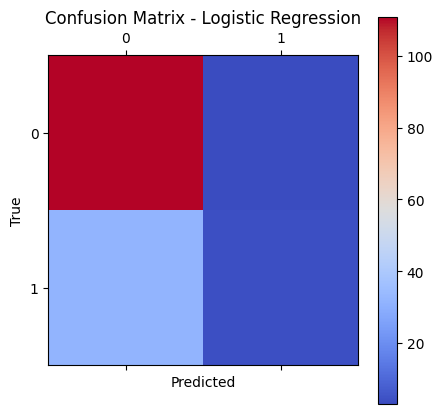

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 5))
plt.matshow(cm, cmap="coolwarm", fignum=1)
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [7]:
df = pd.read_csv("Sample_Blood_Donor_Data(1).csv")

print("First 5 rows of the dataset:\n")
print(df.head())

print("\nDataset Info:\n")
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

df = df.dropna()

target = "Donation"

X = df.drop(columns=[target])
y = df[target]

label_encoders = {}

for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        label_encoders[col] = le

if y.dtype == 'object':
    le_target = LabelEncoder()
    y = le_target.fit_transform(y)

scaler_rf = StandardScaler()
X_scaled = scaler_rf.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("\n=== Random Forest Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

First 5 rows of the dataset:

   Age  Gender Blood_Group  Hemoglobin  Last_Donation_Days  Donation
0   56    Male          A+        12.2                 130         0
1   46  Female         AB+        12.3                 142         1
2   32  Female          A+        11.2                 110         1
3   25  Female         AB-        14.6                 216         1
4   38  Female          A+        11.6                 142         1

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 50 non-null     int64  
 1   Gender              50 non-null     object 
 2   Blood_Group         50 non-null     object 
 3   Hemoglobin          50 non-null     float64
 4   Last_Donation_Days  50 non-null     int64  
 5   Donation            50 non-null     int64  
dtypes: float64(1), int64(3), object(2)
memory

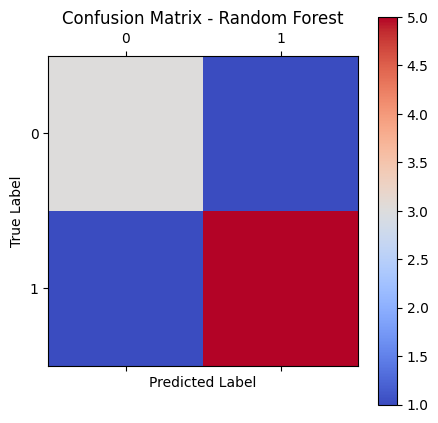

In [8]:
cm_rf = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 5))
plt.matshow(cm_rf, cmap="coolwarm", fignum=1)
plt.title("Confusion Matrix - Random Forest")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [9]:
new_donor = pd.DataFrame([
    {
        "Age": 28,
        "Gender": "Male",
        "Blood_Group": "O+",
        "Hemoglobin": 14.0,
        "Last_Donation_Days": 120
    }
])

for col in new_donor.columns:
    if new_donor[col].dtype == 'object':
        new_donor[col] = label_encoders[col].transform(new_donor[col])

new_donor_scaled = scaler_rf.transform(new_donor)

pred = rf_model.predict(new_donor_scaled)

if 'le_target' in locals():
    pred_label = le_target.inverse_transform(pred)[0]
else:
    pred_label = pred[0]

print("\nPrediction for New Donor:", pred_label)


Prediction for New Donor: 1
